# ${}^{4}{\rm He}$

The interaction is defined in `helium4plusplus.py`. It is nonlocal, and so is the counterterm. 

We will use it to non-perturbatviely calculate NLO phase shifts.

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import scienceplots
from tqdm import tqdm

import mu2

import helium4plusplus as he4

plt.style.use('science')

In [23]:
ELL = 0

# rg_flow = np.loadtxt('datfiles/rgflow_gLO_gNLO_perturbative_nonlocal_2_6_6.dat')
rg_flow = np.loadtxt('datfiles/rg_flows/nonlocal_nlo_np.txt')

In [26]:
ii = np.intersect1d(
    np.where(rg_flow[:, 0] < 2)[0],
    np.where(rg_flow[:, 0] > 1.75)[0]
)

In [27]:
rg_flow[ii, 0]

array([1.9394375 , 1.8322    , 1.813594  , 1.7953    , 1.78632401])

In [28]:
rg_flow = rg_flow[ii, :]

In [29]:
# momenta = np.linspace(0.01/he4.BETA6, 10/he4.BETA6, 100)
momenta = np.loadtxt('datfiles/phase_shifts/momenta.txt')

In [30]:
R, glo, gnlo = rg_flow[0]
s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6, nq=200)

In [31]:
s.a0_and_r0(glo, gnlo, momenta, use_c=True)

(-1.0, 2.0)

In [32]:
phase_shifts = []

for (R, glo, gnlo) in tqdm(rg_flow):
    s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6, nq=200)
    kcd = s.kcotd_gen_fast(momenta, glo, gnlo)
    phase_shifts.append(np.arctan(momenta/kcd))

100%|█████████████████████████████████████████████| 5/5 [00:09<00:00,  1.91s/it]


In [33]:
phase_shifts = np.array(phase_shifts)

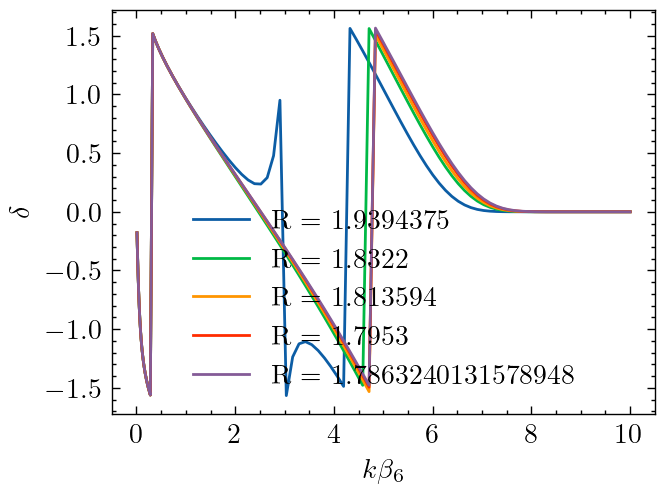

In [38]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

for (i, row) in enumerate(phase_shifts):
    ax.plot(momenta*he4.BETA6, row, label=f'R = {rg_flow[i, 0]}')

ax.set_xlabel(r'$k\beta_6$')
ax.set_ylabel(r'$\delta$')
ax.legend();

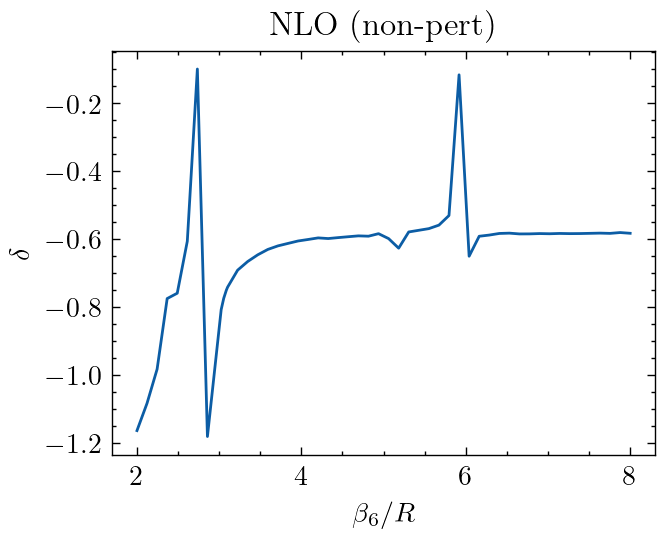

In [40]:
index = 50

fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6/rg_flow[:, 0], phase_shifts[:, index])

ax.set_xlabel(r'$\beta_6/R$')
ax.set_ylabel(r'$\delta$')
ax.set_title('NLO (non-pert)');

In [41]:
phase_shifts.shape

(51, 100)

In [42]:
# np.savetxt('datfiles/phase_shifts/nonlocal_nlo_np.txt', np.vstack((momenta, phase_shifts)).T)